# Synthetic-100 regression: linear-kernel MiSTIC benchmark

This notebook repeats the ten-seed synthetic regression comparison with a
linear kernel inside MiSTIC. Everything else is held fixed relative to the RBF
benchmark: the dataset and blind split, `rank_weight=0.90`, forward-knee search,
`addition_factor=0.1`, `max_features=20`, separate member features and
parameters, final knee retuning, and 5/10/20 members.

Because a linear kernel has no gamma, MiSTIC tunes C and epsilon only. The
sklearn reference definitions remain unchanged so the result can be compared
directly with the preceding RBF-MiSTIC experiment.


In [1]:
import time
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import pearsonr
from sklearn.datasets import make_regression
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, ShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents]
                 if (path / "mistic" / "svmSet.py").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mistic import combined_rank, cvSet, kernelWrapper, paramSet, score_svr, svmSet

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)


Matplotlib is building the font cache; this may take a moment.


In [2]:
N_SAMPLES = 500
N_FEATURES = 100
N_INFORMATIVE = 10
N_REDUNDANT = 10
SIGNAL_FEATURES = set(range(N_INFORMATIVE + N_REDUNDANT))
DATA_SEED = 2026
BLIND_SET_SEED = 42
INNER_SEEDS = list(range(10))
MEMBER_COUNTS = [5, 10, 20]
TEST_SIZE = 0.25
INNER_VALIDATION_SIZE = 0.20
RANK_WEIGHT = 0.90
MAX_FEATURES = 20
ADDITION_FACTOR = 0.1
RFE_FEATURE_COUNT = 20
C_VALUES = [0.25, 1.0, 4.0]
GAMMA_VALUES = [2.0 ** exponent for exponent in (-9, -7, -5)]
EPSILON_VALUES = [0.05, 0.1, 0.2]

# Start with 10 informative plus 80 independent noise predictors. Insert 10
# noisy linear combinations of the informative block as redundant signal.
base_X, y_values, coefficients = make_regression(
    n_samples=N_SAMPLES, n_features=90, n_informative=N_INFORMATIVE,
    noise=20.0, shuffle=False, random_state=DATA_SEED, coef=True,
)
rng = np.random.default_rng(DATA_SEED)
mixing = rng.normal(size=(N_INFORMATIVE, N_REDUNDANT))
redundant = base_X[:, :N_INFORMATIVE] @ mixing
redundant += rng.normal(scale=0.10 * redundant.std(axis=0), size=redundant.shape)
X_values = np.column_stack([base_X[:, :N_INFORMATIVE], redundant, base_X[:, N_INFORMATIVE:]])
X = pd.DataFrame(X_values)
y = pd.Series(y_values, name="target")

X_train, X_blind, y_train_raw, y_blind_raw = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=BLIND_SET_SEED,
)
y_mean = y_train_raw.mean()
y_scale = y_train_raw.std(ddof=0)
y_train = (y_train_raw - y_mean) / y_scale
y_blind = (y_blind_raw - y_mean) / y_scale
print(f"Training rows: {len(X_train)}; fixed blind rows: {len(X_blind)}")
print(f"Training target mean={y_train.mean():.3g}, SD={y_train.std(ddof=0):.3g}")


Training rows: 375; fixed blind rows: 125
Training target mean=0, SD=1


In [3]:
def metric_row(y_true, predictions):
    r = pearsonr(y_true, predictions).statistic
    return {
        "r2": r2_score(y_true, predictions),
        "rmse": root_mean_squared_error(y_true, predictions),
        "mae": mean_absolute_error(y_true, predictions),
        "pearson_r2": r * r,
    }


def recovery(features):
    features = np.asarray(features, dtype=int)
    signal_count = len(set(features).intersection(SIGNAL_FEATURES))
    return signal_count / len(SIGNAL_FEATURES), signal_count / len(features)


def sklearn_grid(seed):
    return GridSearchCV(
        Pipeline([("scale", StandardScaler()), ("svr", SVR(kernel="rbf"))]),
        {"svr__C": C_VALUES, "svr__gamma": GAMMA_VALUES,
         "svr__epsilon": EPSILON_VALUES},
        scoring="r2", cv=KFold(n_splits=4, shuffle=True, random_state=seed),
        n_jobs=-1, refit=True,
    )


def fit_sklearn(features, seed):
    features = np.asarray(features, dtype=int)
    return sklearn_grid(seed).fit(X_train.iloc[:, features], y_train)


def fit_mistic(seed, num_models):
    scaler = StandardScaler().fit(X_train)
    X_scaled = scaler.transform(X_train)
    splits = cvSet(X_scaled, np.asarray(y_train), num_feature_medoids=20,
                   ensemble_validation_size=0.0)
    splitter = ShuffleSplit(n_splits=num_models,
                            test_size=INNER_VALIDATION_SIZE,
                            random_state=seed)
    generated = list(splitter.split(X_scaled, y_train))
    splits.train = [train for train, _ in generated]
    splits.test = [test for _, test in generated]
    splits.type = "regression_shuffle_split"
    ensemble = svmSet(
        SVR(kernel="precomputed"), splits,
        score_method=score_svr(weight=0.0).score,
        kernel=kernelWrapper(type="linear"),
        separate_feature_sets=True, separate_parameters=True,
    )
    grid = [
        paramSet(model={"C": c, "epsilon": epsilon}, kernel={})
        for c in C_VALUES for epsilon in EPSILON_VALUES
    ]
    ensemble.greedy_forward_selection(
        addition_factor=ADDITION_FACTOR, max_features=MAX_FEATURES,
        parameter_grid=grid,
        feature_ranker=combined_rank(weight=RANK_WEIGHT).compute,
        set_for_rank="sample", tune_models_each_step=False,
        post_find_knee=True,
    )
    return scaler, ensemble, ensemble.find_knee(metric="score")


def ranked_unified_features(ensemble, limit):
    unified = set(np.asarray(ensemble.unified_features, dtype=int))
    ranked = np.asarray([f for f in ensemble.unified_sorted_features if f in unified], dtype=int)
    return ranked[:min(int(limit), len(ranked))]


def sklearn_row(method, features, seed, associated_members=0):
    features = np.asarray(features, dtype=int)
    model = fit_sklearn(features, seed)
    predictions = model.predict(X_blind.iloc[:, features])
    recall, precision = recovery(features)
    return {
        "seed": seed, "method": method, "num_models": 1,
        "associated_mistic_members": associated_members,
        "knee_feature_count": np.nan, "mean_member_features": np.nan,
        "num_unified_features": len(features),
        "top20_signal_recall": recall, "top20_signal_precision": precision,
        "member_disagreement": 0.0, "cv_best_score": model.best_score_,
        **metric_row(y_blind, predictions),
    }


## Run the ten-seed paired comparison

The all-feature, RFE, and oracle references do not depend on MiSTIC member
count, so each is fitted once per seed. The unified reference is fitted
separately for every member-count/seed combination because its selected feature
identities are produced by that ensemble.


In [4]:
rows = []
all_features = np.arange(N_FEATURES)
oracle_features = np.arange(N_INFORMATIVE + N_REDUNDANT)
selector_scaler = StandardScaler().fit(X_train)
rfe = RFE(
    estimator=SVR(kernel="linear", C=1.0, epsilon=0.1),
    n_features_to_select=RFE_FEATURE_COUNT, step=0.1,
).fit(selector_scaler.transform(X_train), y_train)
rfe_features = np.flatnonzero(rfe.support_)

for seed in INNER_SEEDS:
    rows.append(sklearn_row("sklearn SVR: all 100 features", all_features, seed))
    rows.append(sklearn_row("sklearn SVR: linear-SVR RFE (20)", rfe_features, seed))
    rows.append(sklearn_row("sklearn SVR oracle: known signal (20)", oracle_features, seed))

for num_models in MEMBER_COUNTS:
    for seed in INNER_SEEDS:
        started = time.perf_counter()
        scaler, ensemble, knee_count = fit_mistic(seed, num_models)
        X_blind_scaled = scaler.transform(X_blind)
        predictions = ensemble.predict(X_blind_scaled)
        top20 = ranked_unified_features(ensemble, 20)
        unified_reference_features = ranked_unified_features(ensemble, knee_count)
        recall, precision = recovery(top20)
        selected_counts = np.asarray([len(f) for f in ensemble.features])
        member_predictions = np.column_stack([
            ensemble.predict(X_blind_scaled, model_index=i)
            for i in range(num_models)
        ])
        residuals = np.asarray(y_blind)[:, None] - member_predictions
        residual_correlations = [
            abs(np.corrcoef(residuals[:, i], residuals[:, j])[0, 1])
            for i in range(num_models) for j in range(i + 1, num_models)
        ]
        rows.append({
            "seed": seed,
            "method": f"MiSTIC linear-SVR forward-knee ({num_models} members)",
            "num_models": num_models, "associated_mistic_members": num_models,
            "knee_feature_count": knee_count,
            "mean_member_features": selected_counts.mean(),
            "num_unified_features": len(ensemble.unified_features),
            "top20_signal_recall": recall, "top20_signal_precision": precision,
            "member_disagreement": 1 - np.mean(residual_correlations),
            "cv_best_score": np.nan,
            **metric_row(y_blind, predictions),
        })
        rows.append(sklearn_row(
            f"sklearn SVR: knee-ranked unified ({num_models}-member source)",
            unified_reference_features, seed, associated_members=num_models,
        ))
        print(f"members={num_models}, seed={seed}, knee={knee_count}, "
              f"elapsed={time.perf_counter() - started:.1f}s")

results = pd.DataFrame(rows)
results_path = repo_root / "validation/Synthetic100_regression_linear_member_count_10seeds_results.csv"
results.to_csv(results_path, index=False)
results


Number of Features: 1, Score: 0.098


Number of Features: 10, Score: 0.966


Number of Features: 19, Score: 0.976


Number of Features: 20, Score: 0.976


Number of Features: 100, Score: 0.973


...

Number of Features: 19, Score: 0.977


Number of Features: 20, Score: 0.977


Number of Features: 100, Score: 0.967


members=20, seed=9, knee=10, elapsed=21.2s


,seed,method,num_models,associated_mistic_members,knee_feature_count,mean_member_features,num_unified_features,top20_signal_recall,top20_signal_precision,member_disagreement,cv_best_score,r2,rmse,mae,pearson_r2
0,0,sklearn SVR: all 100 features,1,0,NaN,NaN,100,1.00,0.20,0.000000,0.961152,0.962747,0.165401,0.136120,0.965058
1,0,sklearn SVR: linear-SVR RFE (20),1,0,NaN,NaN,20,0.75,0.75,0.000000,0.980585,0.971209,0.145408,0.112661,0.971349
2,0,sklearn SVR oracle: known signal (20),1,0,NaN,NaN,20,1.00,1.00,0.000000,0.979331,0.973354,0.139885,0.110659,0.973494
3,1,sklearn SVR: all 100 features,1,0,NaN,NaN,100,1.00,0.20,0.000000,0.961859,0.962747,0.165401,0.136120,0.965058
4,1,sklearn SVR: linear-SVR RFE (20),1,0,NaN,NaN,20,0.75,0.75,0.000000,0.980489,0.971209,0.145408,0.112661,0.971349
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,7,sklearn SVR: knee-ranked unified (20-member so...,1,20,NaN,NaN,10,0.50,1.00,0.000000,0.975194,0.967037,0.155586,0.120448,0.967183
86,8,MiSTIC linear-SVR forward-knee (20 members),20,20,10.0,10.0,21,0.75,0.75,0.219244,NaN,0.949734,0.192129,0.148081,0.949988
87,8,sklearn SVR: knee-ranked unified (20-member so...,1,20,NaN,NaN,10,0.50,1.00,0.000000,0.963126,0.945807,0.199494,0.155357,0.945997
88,9,MiSTIC linear-SVR forward-knee (20 members),20,20,10.0,10.0,21,0.75,0.75,0.255007,NaN,0.951013,0.189670,0.147397,0.951490


In [5]:
metrics = ["r2", "rmse", "mae", "pearson_r2", "knee_feature_count",
           "mean_member_features", "num_unified_features", "top20_signal_recall",
           "top20_signal_precision", "member_disagreement"]
summary = results.groupby("method")[metrics].agg(["mean", "std"])
summary.round(4)


r2            rmse  \
                                                      mean     std    mean   
method                                                                       
MiSTIC linear-SVR forward-knee (10 members)         0.9520  0.0063  0.1874   
MiSTIC linear-SVR forward-knee (20 members)         0.9523  0.0027  0.1872   
MiSTIC linear-SVR forward-knee (5 members)          0.9503  0.0077  0.1905   
sklearn SVR oracle: known signal (20)               0.9734  0.0000  0.1399   
sklearn SVR: all 100 features                       0.9627  0.0000  0.1654   
sklearn SVR: knee-ranked unified (10-member sou...  0.9412  0.0164  0.2058   
sklearn SVR: knee-ranked unified (20-member sou...  0.9497  0.0189  0.1890   
sklearn SVR: knee-ranked unified (5-member source)  0.9431  0.0134  0.2030   
sklearn SVR: linear-SVR RFE (20)                    0.9712  0.0000  0.1454   

                                                               mae          \
                                                       std    mean     std   
method                                                                       
MiSTIC linear-SVR forward-knee (10 members)         0.0119  0.1449  0.0103   
MiSTIC linear-SVR forward-knee (20 members)         0.0054  0.1444  0.0051   
MiSTIC linear-SVR forward-knee (5 members)          0.0147  0.1483  0.0124   
sklearn SVR oracle: known signal (20)               0.0000  0.1107  0.0000   
sklearn SVR: all 100 features                       0.0000  0.1361  0.0000   
sklearn SVR: knee-ranked unified (10-member sou...  0.0310  0.1605  0.0256   
sklearn SVR: knee-ranked unified (20-member sou...  0.0363  0.1475  0.0294   
sklearn SVR: knee-ranked unified (5-member source)  0.0248  0.1577  0.0210   
sklearn SVR: linear-SVR RFE (20)                    0.0000  0.1127  0.0002   

                                                   pearson_r2          \
                                                         mean     std   
method                                                                  
MiSTIC linear-SVR forward-knee (10 members)            0.9523  0.0061   
MiSTIC linear-SVR forward-knee (20 members)            0.9525  0.0027   
MiSTIC linear-SVR forward-knee (5 members)             0.9507  0.0075   
sklearn SVR oracle: known signal (20)                  0.9735  0.0000   
sklearn SVR: all 100 features                          0.9651  0.0000   
sklearn SVR: knee-ranked unified (10-member sou...     0.9413  0.0164   
sklearn SVR: knee-ranked unified (20-member sou...     0.9499  0.0189   
sklearn SVR: knee-ranked unified (5-member source)     0.9433  0.0134   
sklearn SVR: linear-SVR RFE (20)                       0.9713  0.0000   

                                                   knee_feature_count       \
                                                                 mean  std   
method                                                                       
MiSTIC linear-SVR forward-knee (10 members)                      10.0  0.0   
MiSTIC linear-SVR forward-knee (20 members)                      10.0  0.0   
MiSTIC linear-SVR forward-knee (5 members)                       10.0  0.0   
sklearn SVR oracle: known signal (20)                             NaN  NaN   
sklearn SVR: all 100 features                                     NaN  NaN   
sklearn SVR: knee-ranked unified (10-member sou...                NaN  NaN   
sklearn SVR: knee-ranked unified (20-member sou...                NaN  NaN   
sklearn SVR: knee-ranked unified (5-member source)                NaN  NaN   
sklearn SVR: linear-SVR RFE (20)                                  NaN  NaN   

                                                   mean_member_features       \
                                                                   mean  std   
method                                                                         
MiSTIC linear-SVR forward-knee (10 members)                        10.0  0.0   
MiSTIC linear-SVR forward-knee (20 members)     

In [6]:
baseline = results.query("method == 'MiSTIC linear-SVR forward-knee (5 members)'").set_index("seed")
paired_rows = []
for count in [10, 20]:
    candidate_method = f"MiSTIC linear-SVR forward-knee ({count} members)"
    candidate = results.query("method == @candidate_method").set_index("seed")
    for metric in ["r2", "rmse", "mae", "pearson_r2"]:
        improvement = candidate[metric] - baseline[metric]
        if metric in ["rmse", "mae"]:
            improvement = -improvement
        paired_rows.append({
            "comparison": f"{count} minus 5 members", "metric": metric,
            "mean_improvement": improvement.mean(),
            "std_improvement": improvement.std(ddof=1),
            "larger_wins": int((improvement > 0).sum()),
            "ties": int((improvement == 0).sum()),
            "larger_losses": int((improvement < 0).sum()),
        })
paired = pd.DataFrame(paired_rows)
paired.round(4)


,comparison,metric,mean_improvement,std_improvement,larger_wins,ties,larger_losses
0,10 minus 5 members,r2,0.0017,0.0047,5,0,5
1,10 minus 5 members,rmse,0.0031,0.0091,5,0,5
2,10 minus 5 members,mae,0.0033,0.0080,7,0,3
3,10 minus 5 members,pearson_r2,0.0016,0.0046,5,0,5
4,20 minus 5 members,r2,0.0019,0.0076,4,0,6
5,20 minus 5 members,rmse,0.0033,0.0145,4,0,6
6,20 minus 5 members,mae,0.0039,0.0119,5,0,5
7,20 minus 5 members,pearson_r2,0.0018,0.0075,4,0,6


/var/folders/q_/4g9fzlq94y3d38pwjs5rt9f40000gn/T/ipykernel_76407/73385407.py:13: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=plot_data, y="method", x="r2", order=order,


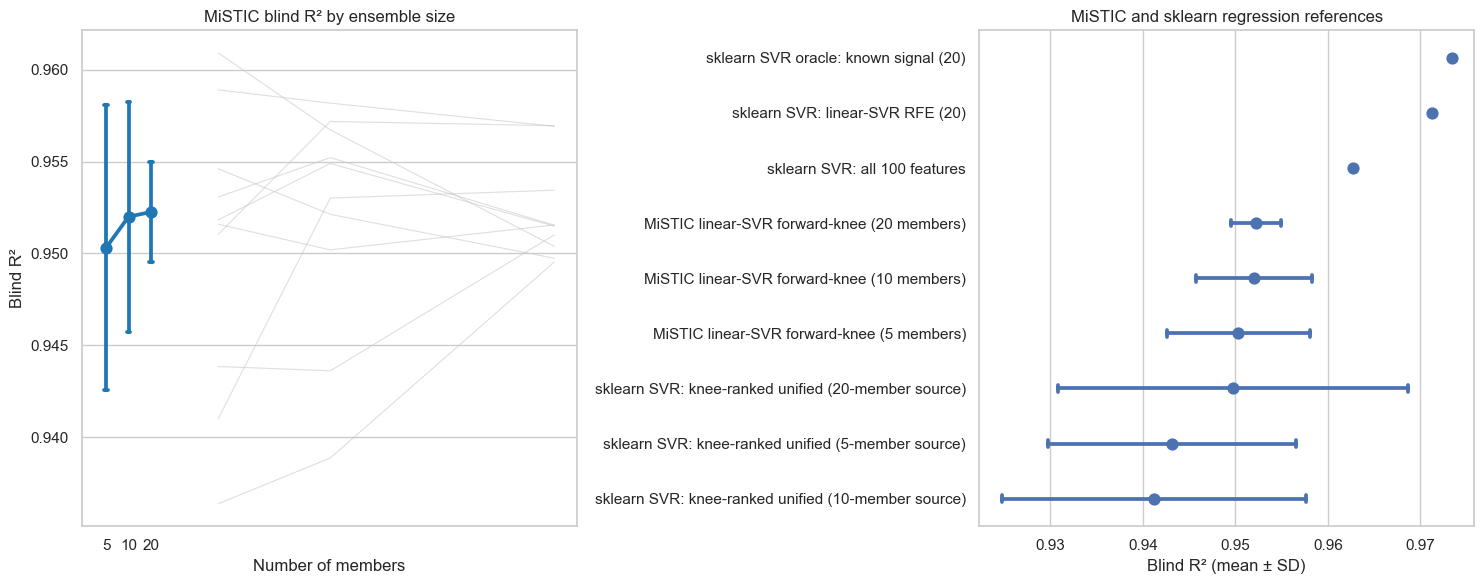

In [7]:
plot_data = results.copy()
order = plot_data.groupby("method")["r2"].mean().sort_values(ascending=False).index
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
mistic_rows = results[results["method"].str.startswith("MiSTIC")]
sns.pointplot(data=mistic_rows, x="num_models", y="r2", errorbar="sd",
              capsize=0.15, color="tab:blue", ax=axes[0])
for _, seed_data in mistic_rows.groupby("seed"):
    axes[0].plot(seed_data["num_models"], seed_data["r2"],
                 color="0.75", alpha=0.5, linewidth=0.8, zorder=0)
axes[0].set_title("MiSTIC blind R² by ensemble size")
axes[0].set_xlabel("Number of members")
axes[0].set_ylabel("Blind R²")
sns.pointplot(data=plot_data, y="method", x="r2", order=order,
              errorbar="sd", join=False, capsize=0.12, ax=axes[1])
axes[1].set_title("MiSTIC and sklearn regression references")
axes[1].set_xlabel("Blind R² (mean ± SD)")
axes[1].set_ylabel("")
plt.tight_layout()
plot_path = repo_root / "validation/Synthetic100_regression_linear_member_count_10seeds.png"
fig.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()


## Interpretation notes

The ten model-building seeds all share one blind set, so their variation
measures sensitivity to inner splitting and selection rather than uncertainty
across independent test samples. The oracle is not a deployable feature
selection method; it quantifies performance when signal identities are known.
